In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [41]:
data_dir = "/Users/cul434/Library/CloudStorage/Dropbox/Jellyfish_Data"
datasets = ["Homeostasis_1", "Homeostasis_2", "Regeneration_1", "Regeneration_2"]
n_datasets = len(datasets)

In [42]:
example_df = pd.read_csv(f"{data_dir}/{datasets[1]}/final_nomouth_processed.csv")
print(example_df.head())
t_max = example_df["t"].max()
print(f"Max time: {t_max}")

   track_id    t           y            x      x_norm       y_norm  \
0       0.0  0.0  653.895197  1440.041439 -700.503289 -1581.533773   
1       0.0  1.0  646.000000  1430.000000 -710.544728 -1589.428970   
2       0.0  2.0  648.000000  1427.000000 -713.544728 -1587.428970   
3       0.0  3.0  678.000000  1431.000000 -709.544728 -1557.428970   
4       0.0  4.0  673.000000  1438.000000 -702.544728 -1562.428970   

             r     theta         dx         dy     motion   jump  real_time  
0  1729.726548 -1.987752        NaN        NaN        NaN  False       0.00  
1  1741.022188 -1.991189 -10.041439  -7.895197  12.773592  False       0.33  
2  1740.424320 -1.993232  -3.000000   2.000000   3.605551  False       0.67  
3  1711.443460 -1.998287   4.000000  30.000000  30.265492  False       1.00  
4  1713.112192 -1.993358   7.000000  -5.000000   8.602325  False       1.33  
Max time: 246.0


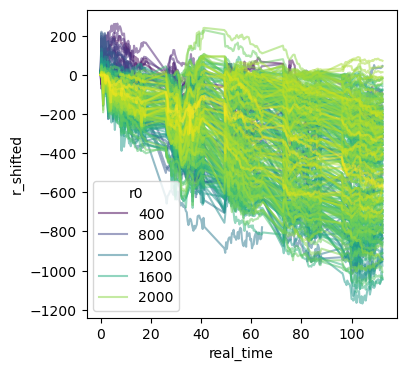

In [43]:
t0 = 0
n_time_steps = t_max 
df_plot = example_df[(example_df["t"] >= t0) & (example_df["t"] < t0 + n_time_steps)].copy()
#subtract t0 from time to make it easier to read
df_plot.t = df_plot.t - t0

#subtract each neuron's initial position from its position at each time step to get the shift in position
df_plot["r_shifted"] = df_plot.r - df_plot.groupby("track_id").r.transform("first")
df_plot["r0"] = df_plot.groupby("track_id").r.transform("first")
#plot the shift in position over time for each neuron, colored by each neuron's initial position
plt.figure(figsize=(4,4))
cs = sns.lineplot(data=df_plot, x="real_time", y="r_shifted", hue="r0", palette="viridis", units="track_id", alpha = 0.5, estimator=None)


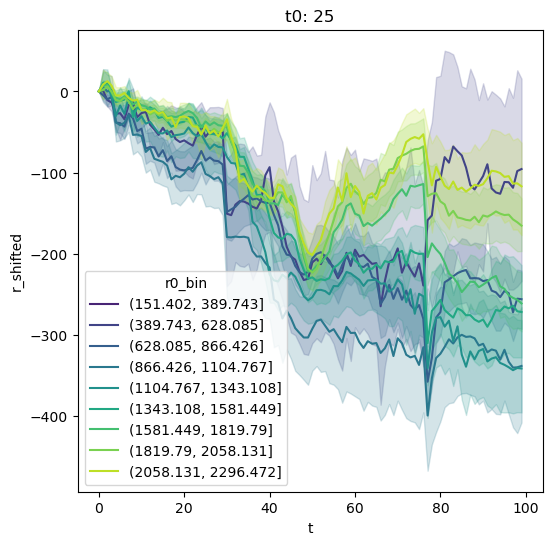

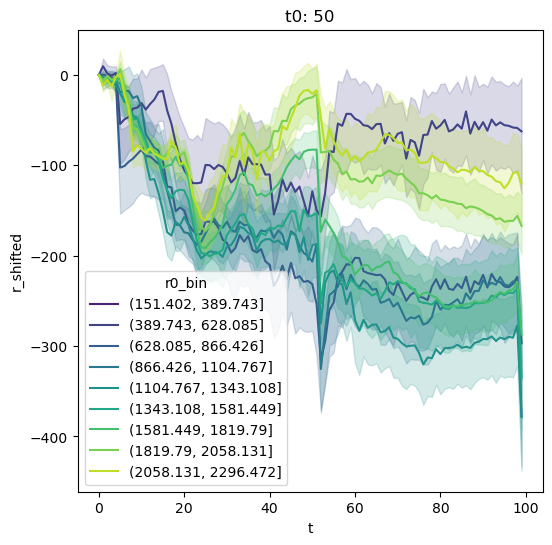

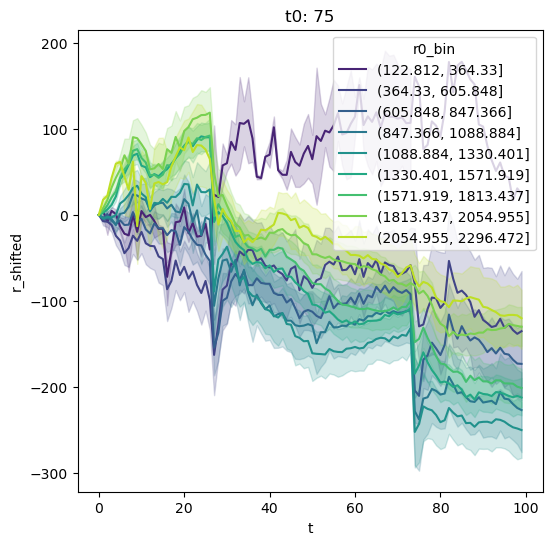

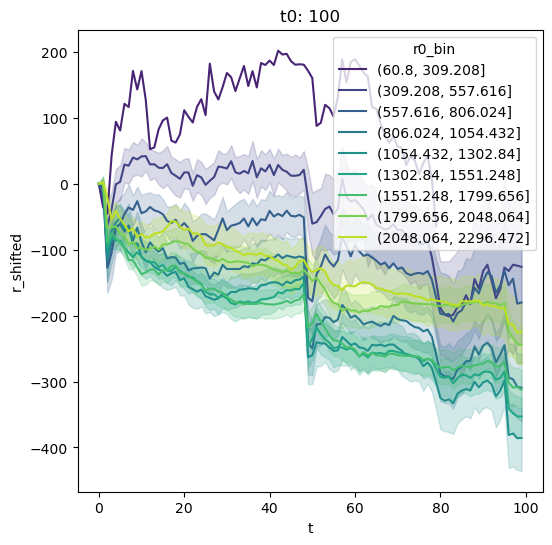

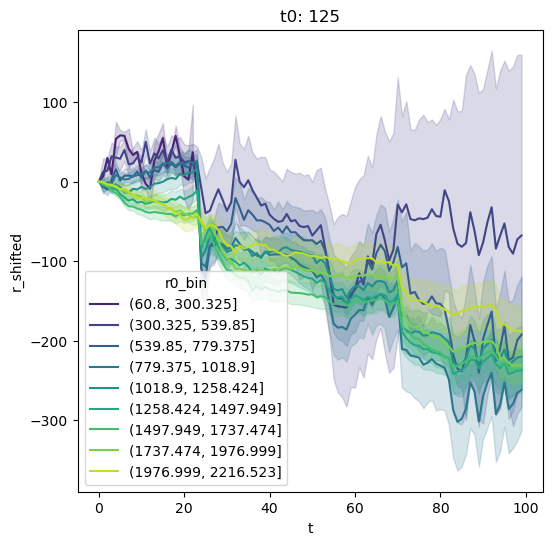

In [44]:
t0s = [25, 50, 75, 100, 125]
n_time_steps = 100 # 300 hours real time
for t0 in t0s:
    df_plot = example_df[(example_df["t"] >= t0) & (example_df["t"] < t0 + n_time_steps)].copy()
    #subtract t0 from time to make it easier to read
    df_plot.t = df_plot.t - t0
    #subtract each neuron's initial position from its position at each time step to get the shift in position
    df_plot["r_shifted"] = df_plot.r - df_plot.groupby("track_id").r.transform("first")
    df_plot["r0"] = df_plot.groupby("track_id").r.transform("first")
    r_max = df_plot.r.max()
    r_min = df_plot.r.min()
    r_bins = np.linspace(r_min, r_max, 10)
    df_plot["r0_bin"] = pd.cut(df_plot.r0, bins=r_bins)
    plt.figure(figsize=(6,6))
    cs = sns.lineplot(data=df_plot, x="t", y="r_shifted", hue="r0_bin", palette="viridis")
    plt.title(f"t0: {t0}")
    plt.show()

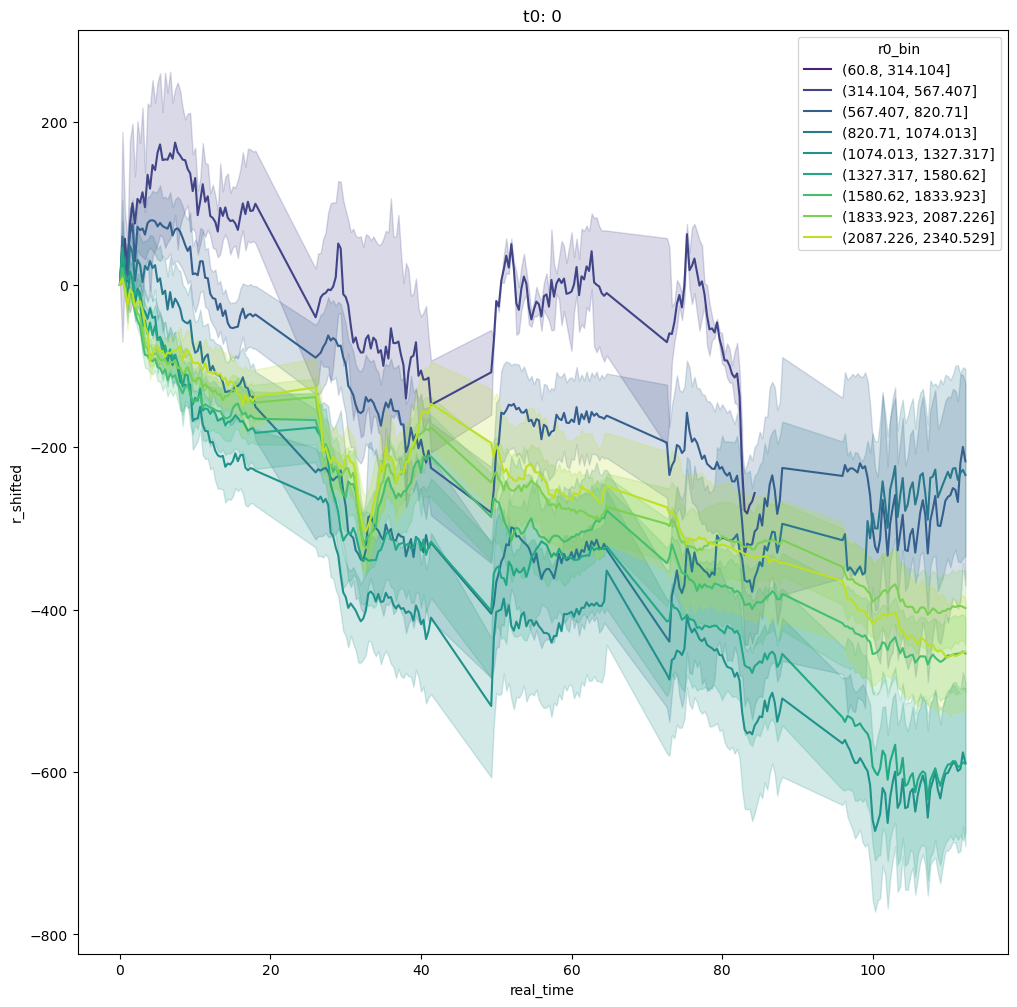

In [45]:
t0 = 0
n_time_steps = t_max 

df_plot = example_df[(example_df["t"] >= t0) & (example_df["t"] < t0 + n_time_steps)].copy()
df_plot.t = df_plot.t - t0
#subtract each neuron's initial position from its position at each time step to get the shift in position
df_plot["r_shifted"] = df_plot.r - df_plot.groupby("track_id").r.transform("first")
df_plot["r0"] = df_plot.groupby("track_id").r.transform("first")
r_max = df_plot.r.max()
r_min = df_plot.r.min()
r_bins = np.linspace(r_min, r_max, 10)
df_plot["r0_bin"] = pd.cut(df_plot.r0, bins=r_bins)
plt.figure(figsize=(12,12))
cs = sns.lineplot(data=df_plot, x="real_time", y="r_shifted", hue="r0_bin", palette="viridis")
plt.title(f"t0: {t0}")
plt.show()